<a href="https://colab.research.google.com/github/mughesaraja/fraud-detection-ml-project/blob/main/fraud_detection_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

train_trans = pd.read_csv('train_transaction.csv')
train_id = pd.read_csv('train_identity.csv')

print(train_trans.shape)
print(train_id.shape)

(590540, 394)
(144233, 41)


In [3]:
df = train_trans.merge(train_id, on='TransactionID', how='left')

print(df.shape)

(590540, 434)


In [4]:
df['isFraud'].value_counts(normalize=True)

,proportion
isFraud,
0,0.96501
1,0.03499


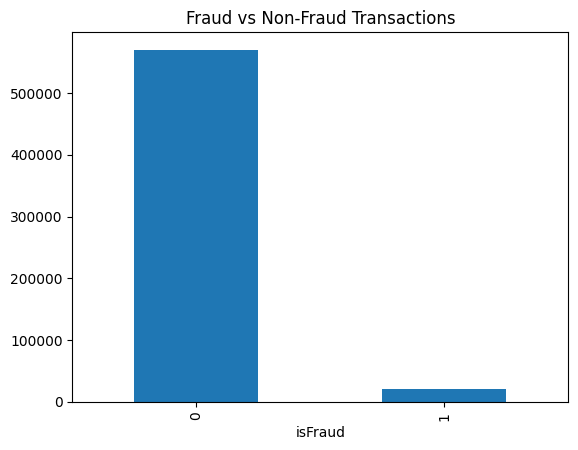

In [5]:
import matplotlib.pyplot as plt

df['isFraud'].value_counts().plot(kind='bar')
plt.title('Fraud vs Non-Fraud Transactions')
plt.show()

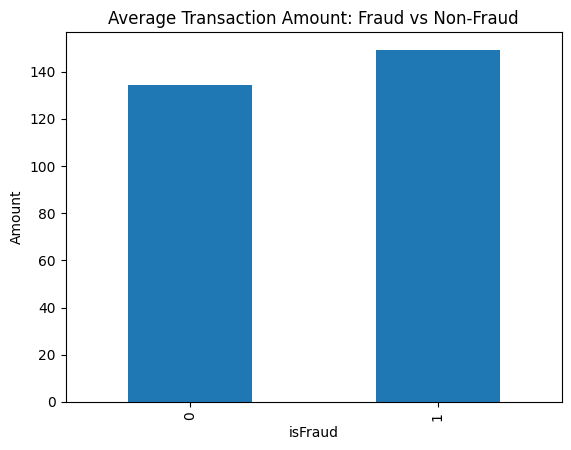

In [6]:
import matplotlib.pyplot as plt

df.groupby('isFraud')['TransactionAmt'].mean().plot(kind='bar')
plt.title('Average Transaction Amount: Fraud vs Non-Fraud')
plt.ylabel('Amount')
plt.show()

In [7]:
df.groupby('ProductCD')['isFraud'].mean().sort_values(ascending=False)

,isFraud
ProductCD,
C,0.116873
S,0.058996
H,0.047662
R,0.037826
W,0.020399


In [8]:
df.groupby('card4')['isFraud'].mean().sort_values(ascending=False)

,isFraud
card4,
discover,0.077282
visa,0.034756
mastercard,0.034331
american express,0.028698


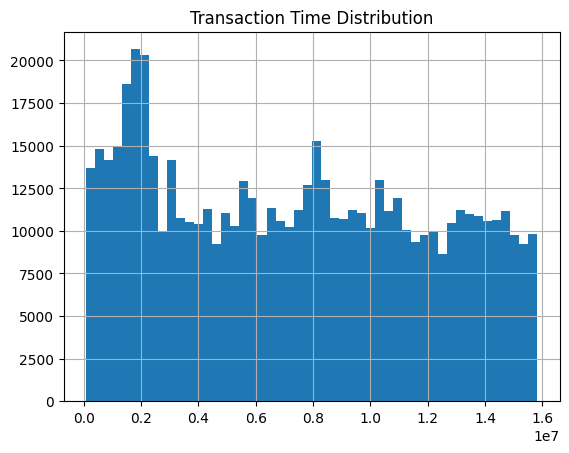

In [9]:
df['TransactionDT'].hist(bins=50)
plt.title('Transaction Time Distribution')
plt.show()

In [10]:
missing = df.isnull().mean().sort_values(ascending=False)
missing.head(20)

,0
id_24,0.991962
id_25,0.991310
id_07,0.991271
id_08,0.991271
id_21,0.991264
id_26,0.991257
id_27,0.991247
id_23,0.991247
id_22,0.991247
dist2,0.936284


In [11]:
cols_to_drop = missing[missing > 0.9].index
df = df.drop(columns=cols_to_drop)

print(len(cols_to_drop), "columns dropped")

12 columns dropped


In [12]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

In [13]:
df_sample = df.sample(n=100000, random_state=42)

In [14]:
num_cols = df_sample.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df_sample.select_dtypes(include=['object']).columns

df_sample[num_cols] = df_sample[num_cols].fillna(df_sample[num_cols].median())
df_sample[cat_cols] = df_sample[cat_cols].fillna('Unknown')

In [15]:
X = df_sample.drop(columns=['isFraud'])
y = df_sample['isFraud']

In [16]:
X = pd.get_dummies(X, drop_first=True)

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split (X, y, test_size=0.2, random_state=42, stratify=y)

In [19]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [20]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99     19285
           1       0.89      0.33      0.48       715

    accuracy                           0.97     20000
   macro avg       0.93      0.66      0.73     20000
weighted avg       0.97      0.97      0.97     20000



In [21]:
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:41:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.98      1.00      0.99     19285
           1       0.81      0.43      0.56       715

    accuracy                           0.98     20000
   macro avg       0.89      0.72      0.78     20000
weighted avg       0.97      0.98      0.97     20000



In [22]:
df_sample = df.sample(n=50000, random_state=42)